In [1]:
import satalign
import matplotlib.pyplot as plt

In [2]:

s2_datacube = satalign.utils.create_array("D:/GitHub/fastcubo/demo2/", "datacube.pickle")
reference_image = s2_datacube.sel(time=s2_datacube.time > "20170225").mean("time")

Creating data cube...


In [3]:
syncmodel = satalign.PCC(
    datacube=s2_datacube, # T x C x H x W
    reference=reference_image, # C x H x W
    channel="mean",
    crop_center=128,
    num_threads=2,
)
news2cube, warps = syncmodel.run_multicore()

c:\Users\contr\.conda\envs\env_deep\Lib\site-packages\satalign\pcc.py:78: UserWarning: Could not determine RMS error between images with the normalized average intensities 128780847953664.0 and 0.0. Either the reference or moving image may be empty.
  shift, error, diffphase = phase_cross_correlation(
c:\Users\contr\.conda\envs\env_deep\Lib\site-packages\satalign\main.py:240: UserWarning: Estimated translation is too large
  warnings.warn("Estimated translation is too large")


(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

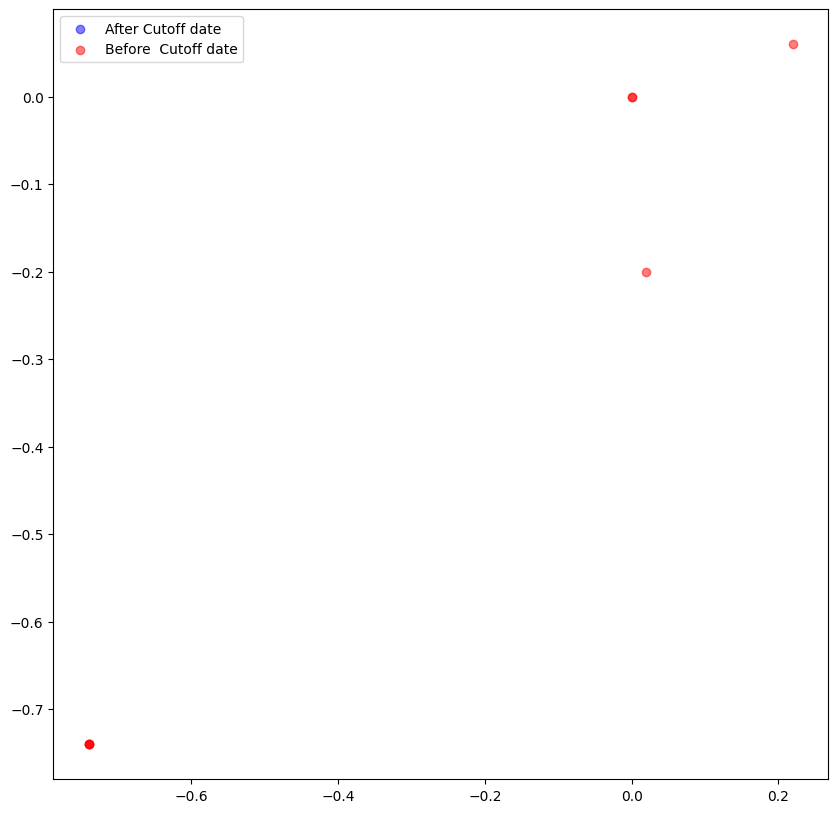

In [8]:
warp_df = satalign.utils.warp2df(warps, s2_datacube.time.values)
satalign.utils.plot_s2_scatter(warp_df)

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: title={'center': 'Original Cube'}, xlabel='X axis - 3', ylabel='Time'>,
        <Axes: title={'center': 'Aligned Cube'}, xlabel='X axis - 3', ylabel='Time'>],
       dtype=object))

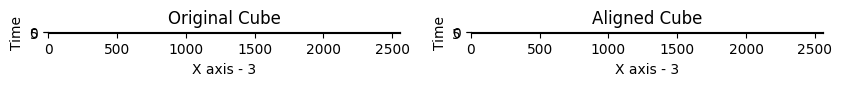

In [5]:
satalign.utils.plot_profile(
    warped_cube=news2cube.values,
    raw_cube=s2_datacube.values,
    x_axis=3,
    y_axis=None,
    rgb_band=[3, 2, 1],
    intensity_factor=1/3000,
)

In [11]:
gifspath = satalign.utils.plot_animation1(
    warped_cube=news2cube[0:4].values,
    raw_cube=s2_datacube[0:4].values,
    dates=s2_datacube.time[0:4].values,
    rgb_band=[3, 2, 1],
    intensity_factor=1/3000,
    png_output_folder="./results2",
    gif_delay=20,
    gif_output_file="./animation1.gif",
)

ValueError: You need to install ImageMagick to create the gif

In [12]:
news2cube[0:4]

<xarray.DataArray (time: 4, band: 4, y: 2560, x: 2560)> Size: 839MB
array([[[[1101.        , 1083.8125    , 1095.40625   , ...,
          1168.84375   , 1151.125     , 1152.8125    ],
         [1089.75      , 1095.26757812, 1099.30273438, ...,
          1177.72070312, 1152.6484375 , 1162.86132812],
         [1099.3125    , 1104.87890625, 1105.0703125 , ...,
          1160.79296875, 1153.8046875 , 1172.70117188],
         ...,
         [1349.0625    , 1351.015625  , 1312.35351562, ...,
           925.33203125,  965.53320312,  982.18359375],
         [1345.6875    , 1367.7578125 , 1365.44140625, ...,
           936.86914062,  956.99609375, 1022.44921875],
         [1247.5       , 1239.44335938, 1243.38867188, ...,
          1013.00390625, 1079.65820312, 1127.015625  ]],

        [[ 929.        ,  942.28125   ,  937.40625   , ...,
          1051.0625    , 1042.5       , 1042.90625   ],
         [ 910.25      ,  893.50195312,  901.45898438, ...,
          1054.72460938, 1042.79296875, 1039.0390625 ],
         [ 936.1875    ,  924.76171875,  924.63867188, ...,
          1069.3828125 , 1065.57617188, 1081.14453125],
...
         [   0.        ,    0.        ,    0.        , ...,
             0.        ,    0.        ,    0.        ],
         [   0.        ,    0.        ,    0.        , ...,
             0.        ,    0.        ,    0.        ],
         [   0.        ,    0.        ,    0.        , ...,
             0.        ,    0.        ,    0.        ]],

        [[   0.        ,    0.        ,    0.        , ...,
             0.        ,    0.        ,    0.        ],
         [   0.        ,    0.        ,    0.        , ...,
             0.        ,    0.        ,    0.        ],
         [   0.        ,    0.        ,    0.        , ...,
             0.        ,    0.        ,    0.        ],
         ...,
         [   0.        ,    0.        ,    0.        , ...,
             0.        ,    0.        ,    0.        ],
         [   0.        ,    0.        ,    0.        , ...,
             0.        ,    0.        ,    0.        ],
         [   0.        ,    0.        ,    0.        , ...,
             0.        ,    0.        ,    0.        ]]]])
Coordinates:
  * time     (time) <U8 128B '20170117' '20170117' '20170127' '20170127'
  * band     (band) int32 16B 1 2 3 4
  * y        (y) float64 20kB 4.089e+06 4.089e+06 ... 4.063e+06 4.063e+06
  * x        (x) float64 20kB 2.476e+05 2.476e+05 ... 2.732e+05 2.732e+05